## Solución Taller 05- Optimización de Redes Metabólicas

In [ ]:
pip install cobra

In [76]:
# Librerías a utilizar en el taller
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cobra
from phenotype_phase_plane import phenotype_phase_plane

# Definir Gurobi como solver
cobra.core.configuration.Configuration(solver="gurobi");

In [77]:
# Cargar el modelo que se utilizará en el taller
model = cobra.io.read_sbml_model("ecoli_core.xml")

### Pregunta a)
Se solicita calcular la velocidad máxima de crecimiento usando los *bounds* por defecto del modelo. Para ello, simplemente hay que ocupar la funcion `optimize()` en el modelo:

In [71]:
# Máxima velocidad de crecimiento
mu_max = model.optimize().objective_value

print(f'Máxima velocidad de crecimiento {mu_max:.3f} 1/h')

Máxima velocidad de crecimiento 0.874 1/h


### Pregunta b)

Para determinar el *Phenotype Phase Plane* se debe utilizar la función adjuntada en el módulo del taller `phenotype_phase_plane` que recibe como *inputs*: modelo, reacción 1, reacción 2, número de puntos a graficar y el rango de cada reacción.

Tener en cuenta que el rango es asumiendo que son ambos sustratos, por lo que se entrega un valor positivo asumiendo que será una tasa de consumo:

In [72]:
# Reacciones de consumo de glucosa y oxígeno
glucose_rxn = "EX_glc(e)"
oxygen_rxn  = "EX_o2(e)"

# Definir los límites de las reacciones
model.reactions.get_by_id(glucose_rxn).lower_bound = -20
model.reactions.get_by_id(oxygen_rxn).lower_bound  = -20


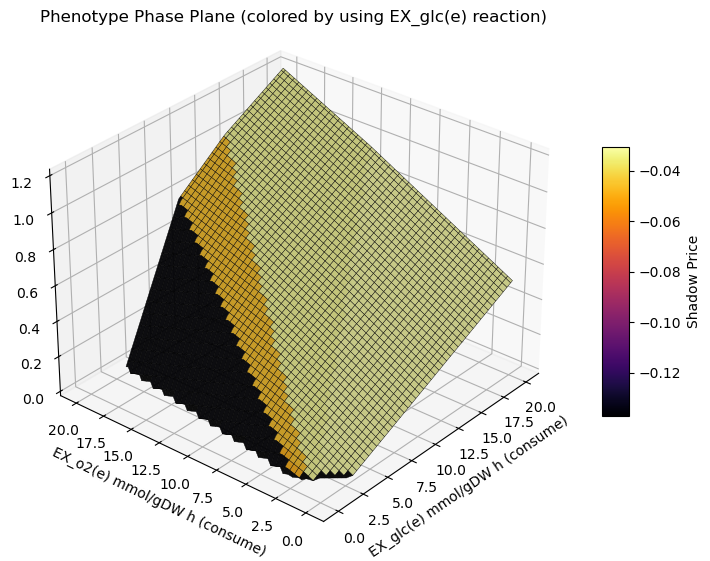

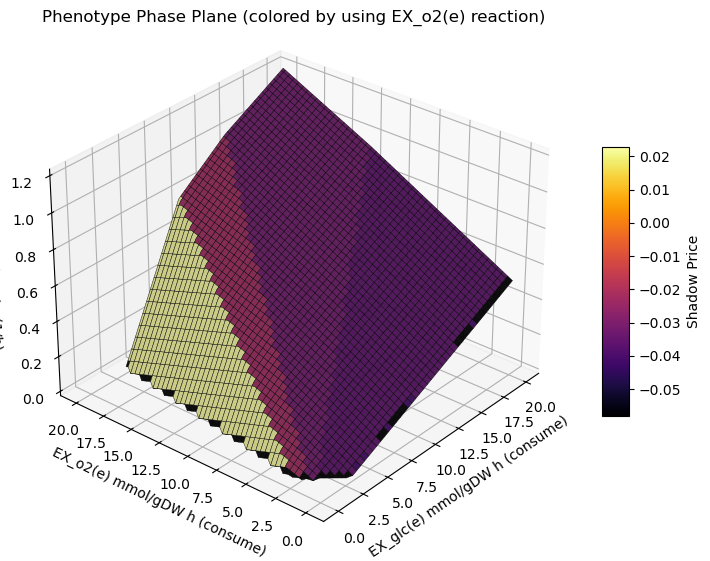

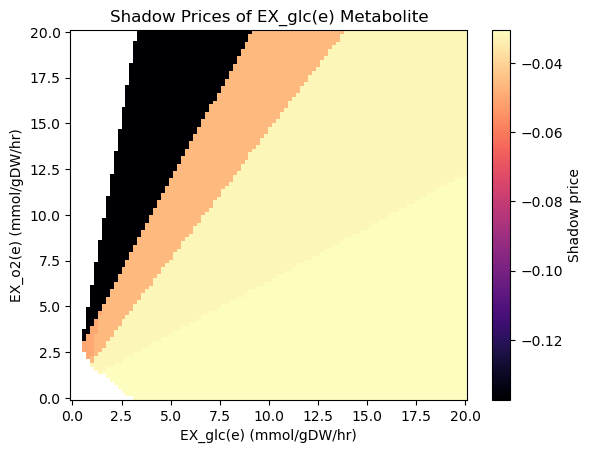

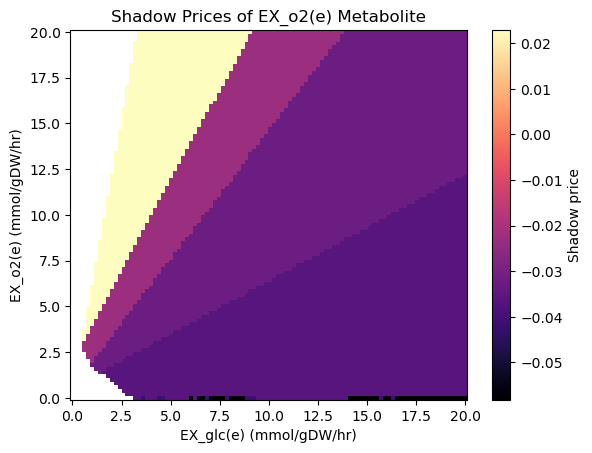

In [91]:
# Ejecutar la función para obtener el Phenotype Phase Plane
growthRates, shadowPrices1, shadowPrices2 = phenotype_phase_plane(model, glucose_rxn, oxygen_rxn, nPts=100, range1=20, range2=20)

### Pregunta c)

Para determinar el perfil de crecimiento en función de cada sustrato, se debe hacer un proceso iterativo donde se fija uno de ellos y se modifica el otro entre el rango solicitado.

Para esta ocasión, se fijarán como límites inferiores de las reacciones -5 mmol/gDW/h. Luego se modificará cada uno entre un rango de -20 y 0. De este modo, se creará un array de velocidades de crecimiento para cada uno de los casos, lo cual servirá para encontrar la línea de optimalidad creciendo bajo estos dos sustratos.

In [88]:
# Primero se hacen copias del modelo para modificar los límites sin afectar el original
model_test = model.copy()

# Se fijan los límites basales de glucosa y oxígeno
model_test.reactions.get_by_id(glucose_rxn).lower_bound = -5
model_test.reactions.get_by_id(oxygen_rxn).lower_bound  = -5

# Copia para cada sustrato, para construir las curvas de optimalidad
model_glc = model_test.copy()
model_o2  = model_test.copy()

Read LP format model from file C:\Users\itapi\AppData\Local\Temp\tmpoc6i1akn.lp
Reading time = 0.01 seconds
: 72 rows, 190 columns, 720 nonzeros
Read LP format model from file C:\Users\itapi\AppData\Local\Temp\tmpm803dsfl.lp
Reading time = 0.02 seconds
: 72 rows, 190 columns, 720 nonzeros
Read LP format model from file C:\Users\itapi\AppData\Local\Temp\tmppvz79uil.lp
Reading time = 0.02 seconds
: 72 rows, 190 columns, 720 nonzeros


c:\Users\itapi\miniconda3\envs\Cobra\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


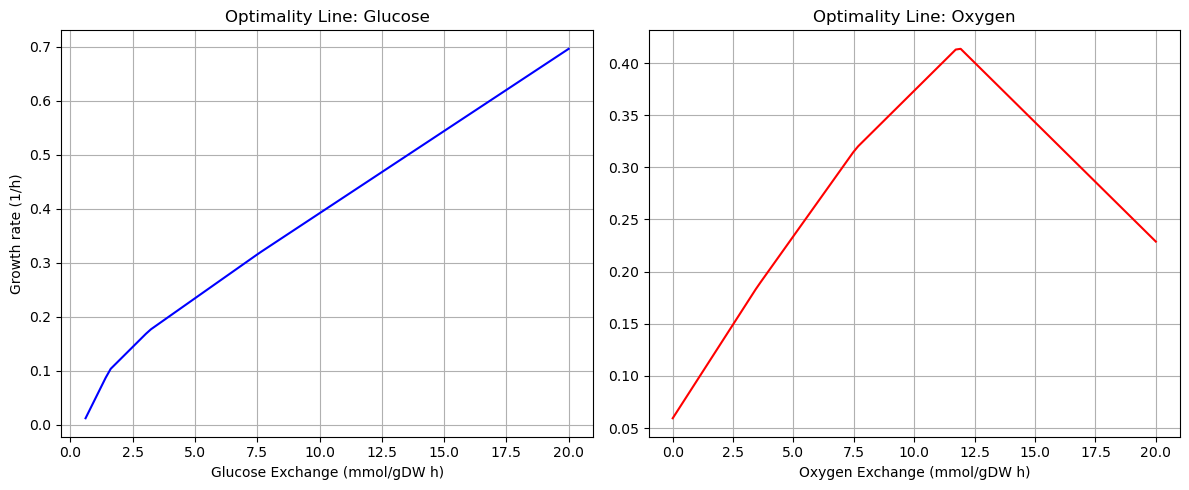

In [92]:
# Crear rango de análisis
rango = np.linspace(0, 20, 100)

# Inicializar resultados
GLC_range = np.zeros(100)
O2_range  = np.zeros(100)

for i, val in enumerate(rango):
    # Variar glucosa manteniendo oxígeno fijo
    model_glc.reactions.get_by_id(glucose_rxn).bounds = (-val, -val)
    GLC_range[i] = model_glc.optimize().objective_value

    # Variar oxígeno manteniendo glucosa fija
    model_o2.reactions.get_by_id(oxygen_rxn).bounds   = (-val, -val)
    O2_range[i] = model_o2.optimize().objective_value

# Graficar resultados
fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].plot(rango, GLC_range, color='b')
axs[0].set_xlabel('Glucose Exchange (mmol/gDW h)')
axs[0].set_ylabel('Growth rate (1/h)')
axs[0].grid(True)
axs[0].set_title('Optimality Line: Glucose')

axs[1].plot(rango, O2_range, color='r')
axs[1].set_xlabel('Oxygen Exchange (mmol/gDW h)')
axs[1].grid(True)
axs[1].set_title('Optimality Line: Oxygen')

plt.tight_layout()
plt.show()

Se observa que, bajo un nivel constante de consumo de oxígeno, la tasa de crecimiento celular presenta una relación estrictamente creciente con el consumo de carbono (glucosa). Este comportamiento refleja la dependencia directa de la biomasa respecto al aporte de carbono cuando el oxígeno no es un factor limitante.

Por otro lado, al analizar el efecto del oxígeno, se evidencia un comportamiento distinto. La tasa de crecimiento aumenta con el consumo de oxígeno hasta alcanzar un valor cercano a 12 mmol/gDW/h (en valor absoluto). A partir de este punto crítico, la velocidad de crecimiento sufre una caída abrupta. Este fenómeno indica que el oxígeno, inicialmente en exceso, deja de ser un factor ilimitado y su consumo adicional no se traduce en un incremento de biomasa. De hecho, forzar un mayor flujo de oxígeno en esta región se asocia a una penalización metabólica que conduce a una reducción en la tasa de crecimiento. Esto es consistente con la transición desde un régimen oxígeno-limitado a uno carbono-limitado.

Por lo tanto, la línea de optimalidad se encuentra entre las zonas P1 y P2 del espacio de fases. La región P1 corresponde a un régimen de exceso de oxígeno, mientras que en P2 se inicia un déficit relativo de oxígeno respecto a la cantidad de glucosa. La línea de optimalidad representa el compromiso metabólico óptimo entre ambos sustratos y es, además, la región de mayor pendiente (sin considerar las zonas donde no hay crecimiento o donde se está en exceso absoluto de un sustrato).